In [1]:
# load config and graph AnnData, convert to PyG Data object
import os
os.chdir("C:/Users/ASRENOVIN/Desktop/spatial-foundation-graph-transformer")

import yaml
import numpy as np
import torch
import anndata as ad
from torch_geometric.data import Data

with open("configs/default.yaml") as f:
    cfg = yaml.safe_load(f)

adata = ad.read_h5ad("data/processed/adata_graph.h5ad")

X          = torch.tensor(adata.obsm["X_embedding"], dtype=torch.float32)
edge_index = torch.tensor(adata.uns["spatial_graph"]["edge_index"], dtype=torch.long)
edge_attr  = torch.tensor(adata.uns["spatial_graph"]["edge_weights"], dtype=torch.float32)

graph_data = Data(x=X, edge_index=edge_index, edge_attr=edge_attr)

print(graph_data)
print("\nNode features shape:", graph_data.x.shape)
print("Edge index shape   :", graph_data.edge_index.shape)
print("Edge attr shape    :", graph_data.edge_attr.shape)

Data(x=[3661, 50], edge_index=[2, 21966], edge_attr=[21966])

Node features shape: torch.Size([3661, 50])
Edge index shape   : torch.Size([2, 21966])
Edge attr shape    : torch.Size([21966])


In [3]:
# write_mlp_and_gcn: write MLP baseline and GCN to src/models/
mlp_code = '''from __future__ import annotations
import torch
import torch.nn as nn


class MLP(nn.Module):
    """
    Baseline MLP — operates on node features only, ignores graph structure.

    Architecture: Linear -> LayerNorm -> ReLU -> Dropout, repeated n_layers times.
    Final layer projects to output_dim (the latent representation).
    """

    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int,
                 n_layers: int = 3, dropout: float = 0.1) -> None:
        super().__init__()
        dims = [input_dim] + [hidden_dim] * (n_layers - 1) + [output_dim]
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            if i < len(dims) - 2:
                layers.append(nn.LayerNorm(dims[i + 1]))
                layers.append(nn.ReLU())
                layers.append(nn.Dropout(dropout))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor, edge_index=None, edge_attr=None) -> torch.Tensor:
        return self.net(x)
'''

gcn_code = '''from __future__ import annotations
import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv


class GCN(nn.Module):
    """
    Graph Convolutional Network (Kipf & Welling 2017).

    Each layer aggregates features from 1-hop neighbors via normalized
    adjacency multiplication. Uses residual connections when dims match.
    """

    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int,
                 n_layers: int = 3, dropout: float = 0.1) -> None:
        super().__init__()
        dims = [input_dim] + [hidden_dim] * (n_layers - 1) + [output_dim]
        self.convs = nn.ModuleList([
            GCNConv(dims[i], dims[i + 1]) for i in range(len(dims) - 1)
        ])
        self.norms = nn.ModuleList([
            nn.LayerNorm(dims[i + 1]) for i in range(len(dims) - 2)
        ])
        self.dropout = nn.Dropout(dropout)
        self.act = nn.ReLU()

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor,
                edge_attr=None) -> torch.Tensor:
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = self.norms[i](x)
                x = self.act(x)
                x = self.dropout(x)
        return x
'''

with open("src/models/mlp.py", "w", encoding="utf-8") as f:
    f.write(mlp_code)

with open("src/models/gcn.py", "w", encoding="utf-8") as f:
    f.write(gcn_code)

print("Created: src/models/mlp.py")
print("Created: src/models/gcn.py")

Created: src/models/mlp.py
Created: src/models/gcn.py


In [4]:
# write graphsage & graph transformer(implement the two main graph models)
graphsage_code = '''from __future__ import annotations
import torch
import torch.nn as nn
from torch_geometric.nn import SAGEConv


class GraphSAGE(nn.Module):
    """
    GraphSAGE (Hamilton et al. 2017).

    Aggregates neighbor features via mean pooling and concatenates
    with the central node embedding. More scalable than GCN as it
    samples a fixed neighborhood rather than using the full adjacency.
    """

    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int,
                 n_layers: int = 3, dropout: float = 0.1,
                 aggr: str = "mean") -> None:
        super().__init__()
        dims = [input_dim] + [hidden_dim] * (n_layers - 1) + [output_dim]
        self.convs = nn.ModuleList([
            SAGEConv(dims[i], dims[i + 1], aggr=aggr)
            for i in range(len(dims) - 1)
        ])
        self.norms = nn.ModuleList([
            nn.LayerNorm(dims[i + 1]) for i in range(len(dims) - 2)
        ])
        self.dropout = nn.Dropout(dropout)
        self.act = nn.ReLU()

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor,
                edge_attr=None) -> torch.Tensor:
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = self.norms[i](x)
                x = self.act(x)
                x = self.dropout(x)
        return x
'''

gt_code = '''from __future__ import annotations
import torch
import torch.nn as nn
from torch_geometric.nn import TransformerConv


class GraphTransformer(nn.Module):
    """
    Graph Transformer using TransformerConv (Shi et al. 2021).

    Each layer computes multi-head attention over the local neighborhood,
    allowing each node to selectively weight its neighbors. This is the
    main architecture of interest for spatial representation learning.

    Attention weights are stored in self.attention_weights after each
    forward pass for visualization.
    """

    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int,
                 n_layers: int = 4, n_heads: int = 8,
                 dropout: float = 0.1, edge_dim: int = None) -> None:
        super().__init__()

        assert hidden_dim % n_heads == 0, "hidden_dim must be divisible by n_heads"

        dims = [input_dim] + [hidden_dim] * (n_layers - 1) + [output_dim]
        self.convs = nn.ModuleList([
            TransformerConv(
                in_channels=dims[i],
                out_channels=dims[i + 1] // n_heads,
                heads=n_heads,
                dropout=dropout,
                edge_dim=edge_dim,
                concat=True if i < n_layers - 1 else False,
                beta=True,
            )
            for i in range(n_layers)
        ])
        self.norms = nn.ModuleList([
            nn.LayerNorm(dims[i + 1]) for i in range(n_layers - 1)
        ])
        self.dropout = nn.Dropout(dropout)
        self.act = nn.ReLU()
        self.attention_weights = []

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor,
                edge_attr: torch.Tensor = None) -> torch.Tensor:
        self.attention_weights = []
        for i, conv in enumerate(self.convs):
            x, attn = conv(x, edge_index, edge_attr=edge_attr,
                           return_attention_weights=True)
            self.attention_weights.append(attn)
            if i < len(self.convs) - 1:
                x = self.norms[i](x)
                x = self.act(x)
                x = self.dropout(x)
        return x
'''

with open("src/models/graphsage.py", "w", encoding="utf-8") as f:
    f.write(graphsage_code)

with open("src/models/graph_transformer.py", "w", encoding="utf-8") as f:
    f.write(gt_code)

print("Created: src/models/graphsage.py")
print("Created: src/models/graph_transformer.py")

Created: src/models/graphsage.py
Created: src/models/graph_transformer.py


In [5]:
# write_model_factory: register all models behind a single get_model() function
factory_code = '''from __future__ import annotations
from typing import Any
import torch.nn as nn
from models.mlp import MLP
from models.gcn import GCN
from models.graphsage import GraphSAGE
from models.graph_transformer import GraphTransformer


def get_model(cfg: dict[str, Any]) -> nn.Module:
    """
    Instantiate the model specified in cfg["training"]["model"].

    Supported keys: "mlp", "gcn", "graphsage", "graph_transformer"
    """
    key        = cfg["training"].get("model", "graph_transformer")
    input_dim  = cfg["models"]["input_dim"]
    hidden_dim = cfg["models"]["hidden_dim"]
    output_dim = cfg["models"]["output_dim"]
    dropout    = cfg["models"]["dropout"]

    if key == "mlp":
        return MLP(input_dim, hidden_dim, output_dim,
                   n_layers=cfg["models"]["mlp"]["n_layers"],
                   dropout=dropout)

    if key == "gcn":
        return GCN(input_dim, hidden_dim, output_dim,
                   n_layers=cfg["models"]["gcn"]["n_layers"],
                   dropout=dropout)

    if key == "graphsage":
        return GraphSAGE(input_dim, hidden_dim, output_dim,
                         n_layers=cfg["models"]["graphsage"]["n_layers"],
                         dropout=dropout,
                         aggr=cfg["models"]["graphsage"]["aggr"])

    if key == "graph_transformer":
        return GraphTransformer(input_dim, hidden_dim, output_dim,
                                n_layers=cfg["models"]["graph_transformer"]["n_layers"],
                                n_heads=cfg["models"]["graph_transformer"]["n_heads"],
                                dropout=dropout)

    raise NotImplementedError(f"Model \'{key}\' is not registered in the factory.")
'''

with open("src/models/factory.py", "w", encoding="utf-8") as f:
    f.write(factory_code)

print("Created: src/models/factory.py")

# verify: instantiate all four models and count parameters
from src.models.mlp import MLP
from src.models.gcn import GCN
from src.models.graphsage import GraphSAGE
from src.models.graph_transformer import GraphTransformer

input_dim  = cfg["models"]["input_dim"]
hidden_dim = cfg["models"]["hidden_dim"]
output_dim = cfg["models"]["output_dim"]
dropout    = cfg["models"]["dropout"]

models = {
    "MLP"              : MLP(input_dim, hidden_dim, output_dim, dropout=dropout),
    "GCN"              : GCN(input_dim, hidden_dim, output_dim, dropout=dropout),
    "GraphSAGE"        : GraphSAGE(input_dim, hidden_dim, output_dim, dropout=dropout),
    "GraphTransformer" : GraphTransformer(input_dim, hidden_dim, output_dim, dropout=dropout),
}

print(f"\n{'Model':<22} {'Parameters':>12}")
print("-" * 36)
for name, model in models.items():
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{name:<22} {n_params:>12,}")

Created: src/models/factory.py

Model                    Parameters
------------------------------------
MLP                          27,680
GCN                          27,680
GraphSAGE                    54,560
GraphTransformer            173,040


In [7]:
# quick_forward_pass (confirm all models produce correct output shapes)

import torch

x          = graph_data.x
edge_index = graph_data.edge_index

print(f"{'Model':<22} {'Output shape'}")
print("-" * 40)
for name, model in models.items():
    model.eval()
    with torch.no_grad():
        out = model(x, edge_index, edge_attr=None)
    print(f"{name:<22} {str(out.shape)}")

Model                  Output shape
----------------------------------------
MLP                    torch.Size([3661, 32])
GCN                    torch.Size([3661, 32])
GraphSAGE              torch.Size([3661, 32])
GraphTransformer       torch.Size([3661, 4])


In [8]:
# fix_graph_transformer: fix output dim in the last TransformerConv layer
gt_code = '''from __future__ import annotations
import torch
import torch.nn as nn
from torch_geometric.nn import TransformerConv


class GraphTransformer(nn.Module):
    """
    Graph Transformer using TransformerConv (Shi et al. 2021).

    Each layer computes multi-head attention over the local neighborhood.
    Attention weights are stored in self.attention_weights after each
    forward pass for visualization.
    """

    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int,
                 n_layers: int = 4, n_heads: int = 8,
                 dropout: float = 0.1, edge_dim: int = None) -> None:
        super().__init__()

        assert hidden_dim % n_heads == 0, "hidden_dim must be divisible by n_heads"

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        for i in range(n_layers):
            is_last = (i == n_layers - 1)
            in_ch   = input_dim if i == 0 else hidden_dim
            # last layer: concat=False so out_channels = output_dim directly
            # middle layers: concat=True so total output = out_channels * n_heads = hidden_dim
            out_ch  = output_dim if is_last else hidden_dim // n_heads
            self.convs.append(TransformerConv(
                in_channels=in_ch,
                out_channels=out_ch,
                heads=n_heads,
                dropout=dropout,
                edge_dim=edge_dim,
                concat=not is_last,
                beta=True,
            ))
            if not is_last:
                self.norms.append(nn.LayerNorm(hidden_dim))

        self.dropout = nn.Dropout(dropout)
        self.act = nn.ReLU()
        self.attention_weights = []

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor,
                edge_attr: torch.Tensor = None) -> torch.Tensor:
        self.attention_weights = []
        for i, conv in enumerate(self.convs):
            x, attn = conv(x, edge_index, edge_attr=edge_attr,
                           return_attention_weights=True)
            self.attention_weights.append(attn)
            if i < len(self.convs) - 1:
                x = self.norms[i](x)
                x = self.act(x)
                x = self.dropout(x)
        return x
'''

with open("src/models/graph_transformer.py", "w", encoding="utf-8") as f:
    f.write(gt_code)

print("Fixed: src/models/graph_transformer.py")

# re-instantiate and re-run forward pass
from importlib import reload
import src.models.graph_transformer as gt_module
reload(gt_module)
from src.models.graph_transformer import GraphTransformer

models["GraphTransformer"] = GraphTransformer(input_dim, hidden_dim, output_dim, dropout=dropout)

print(f"\n{'Model':<22} {'Output shape'}")
print("-" * 40)
for name, model in models.items():
    model.eval()
    with torch.no_grad():
        out = model(x, edge_index, edge_attr=None)
    print(f"{name:<22} {str(out.shape)}")

Fixed: src/models/graph_transformer.py

Model                  Output shape
----------------------------------------
MLP                    torch.Size([3661, 32])
GCN                    torch.Size([3661, 32])
GraphSAGE              torch.Size([3661, 32])
GraphTransformer       torch.Size([3661, 32])


In [10]:
# write training module (write contrastive loss and Trainer class to src/training)

loss_code = '''from __future__ import annotations
import torch
import torch.nn as nn
import torch.nn.functional as F


class NTXentLoss(nn.Module):
    """
    Normalized Temperature-scaled Cross Entropy Loss (SimCLR).

    Given two augmented views of the same graph, pulls together
    embeddings of the same node and pushes apart embeddings of
    different nodes within the batch.
    """

    def __init__(self, temperature: float = 0.07) -> None:
        super().__init__()
        self.temperature = temperature

    def forward(self, z1: torch.Tensor, z2: torch.Tensor) -> torch.Tensor:
        z1 = F.normalize(z1, dim=1)
        z2 = F.normalize(z2, dim=1)
        N  = z1.size(0)

        z  = torch.cat([z1, z2], dim=0)
        sim = torch.mm(z, z.T) / self.temperature

        # mask out self-similarity
        mask = torch.eye(2 * N, dtype=torch.bool, device=z.device)
        sim.masked_fill_(mask, float("-inf"))

        # positive pairs: (i, i+N) and (i+N, i)
        labels = torch.cat([torch.arange(N, 2*N), torch.arange(N)]).to(z.device)
        loss   = F.cross_entropy(sim, labels)
        return loss
'''

trainer_code = '''from __future__ import annotations
from typing import Any
import torch
import torch.nn as nn
from torch_geometric.data import Data
from training.augmentation import augment
from training.loss import NTXentLoss


class Trainer:
    """
    Full training loop for unsupervised contrastive learning on a spatial graph.

    For each epoch:
        1. Apply two random augmentations to the graph (drop features, drop edges)
        2. Run both views through the model
        3. Compute NT-Xent loss between the two embedding sets
        4. Backpropagate and update weights
        5. Apply early stopping on loss plateau
    """

    def __init__(self, cfg: dict[str, Any], graph_data: Data,
                 model: nn.Module) -> None:
        self.cfg        = cfg
        self.graph_data = graph_data
        self.model      = model
        self.loss_fn    = NTXentLoss(temperature=cfg["training"]["contrastive"]["temperature"])

        opt_cfg = cfg["training"]
        self.optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=opt_cfg["lr"],
            weight_decay=opt_cfg["weight_decay"],
        )
        self.epochs   = opt_cfg["epochs"]
        self.patience = opt_cfg["patience"]
        self.log_every = cfg["logging"]["log_every_n"]
        self.history  = []

    def train(self) -> list[float]:
        aug_cfg   = self.cfg["training"]["contrastive"]
        best_loss = float("inf")
        patience  = 0

        for epoch in range(1, self.epochs + 1):
            self.model.train()

            v1 = augment(self.graph_data, aug_cfg["augment_drop_feat"],
                         aug_cfg["augment_drop_edge"])
            v2 = augment(self.graph_data, aug_cfg["augment_drop_feat"],
                         aug_cfg["augment_drop_edge"])

            z1 = self.model(v1.x, v1.edge_index)
            z2 = self.model(v2.x, v2.edge_index)

            loss = self.loss_fn(z1, z2)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            self.history.append(loss.item())

            if epoch % self.log_every == 0:
                print(f"Epoch {epoch:>4d}/{self.epochs}  loss={loss.item():.4f}")

            if loss.item() < best_loss - 1e-4:
                best_loss = loss.item()
                patience  = 0
            else:
                patience += 1
                if patience >= self.patience:
                    print(f"Early stopping at epoch {epoch}.")
                    break

        return self.history
'''

augment_code = '''from __future__ import annotations
import torch
from torch_geometric.data import Data


def augment(data: Data, drop_feat_prob: float = 0.1,
            drop_edge_prob: float = 0.1) -> Data:
    """
    Apply stochastic augmentations to a PyG Data object.

    Augmentations:
        - Feature masking: randomly zero out node features with probability drop_feat_prob
        - Edge dropout:    randomly remove edges with probability drop_edge_prob

    Returns a new Data object; the original is not modified.
    """
    x          = data.x.clone()
    edge_index = data.edge_index.clone()

    # feature masking
    if drop_feat_prob > 0:
        mask = torch.bernoulli(
            torch.full(x.shape, 1 - drop_feat_prob)
        ).bool()
        x = x * mask

    # edge dropout
    if drop_edge_prob > 0:
        n_edges  = edge_index.size(1)
        keep     = torch.bernoulli(
            torch.full((n_edges,), 1 - drop_edge_prob)
        ).bool()
        edge_index = edge_index[:, keep]

    return Data(x=x, edge_index=edge_index)
'''

with open("src/training/loss.py", "w", encoding="utf-8") as f:
    f.write(loss_code)

with open("src/training/trainer.py", "w", encoding="utf-8") as f:
    f.write(trainer_code)

with open("src/training/augmentation.py", "w", encoding="utf-8") as f:
    f.write(augment_code)

print("Created: src/training/loss.py")
print("Created: src/training/trainer.py")
print("Created: src/training/augmentation.py")

Created: src/training/loss.py
Created: src/training/trainer.py
Created: src/training/augmentation.py


Epoch   10/200  loss=4.3793
Epoch   20/200  loss=3.6454
Epoch   30/200  loss=3.2760
Epoch   40/200  loss=2.9990
Epoch   50/200  loss=2.8359
Epoch   60/200  loss=2.6046
Epoch   70/200  loss=2.4521
Epoch   80/200  loss=2.2604
Epoch   90/200  loss=2.1472
Epoch  100/200  loss=1.9934
Epoch  110/200  loss=1.9240
Epoch  120/200  loss=1.8188
Epoch  130/200  loss=1.7485
Epoch  140/200  loss=1.6576
Epoch  150/200  loss=1.5935
Epoch  160/200  loss=1.5290
Epoch  170/200  loss=1.4858
Epoch  180/200  loss=1.4254
Epoch  190/200  loss=1.3834
Epoch  200/200  loss=1.3360


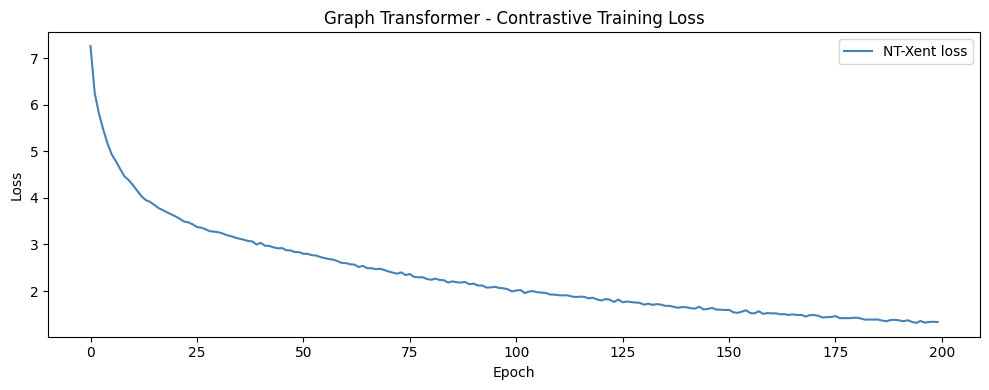

Training complete. Final loss: 1.3360


In [11]:
# run training (train Graph Transformer with contrastive loss and plot loss curve)
import matplotlib.pyplot as plt
from src.training.trainer import Trainer
from src.utils.seed import set_global_seed

set_global_seed(cfg["seed"])

model = models["GraphTransformer"]
trainer = Trainer(cfg, graph_data, model)
history = trainer.train()

# plot loss curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history, color="steelblue", linewidth=1.5, label="NT-Xent loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Graph Transformer - Contrastive Training Loss")
ax.legend()
plt.tight_layout()
plt.savefig("figures/training/graph_transformer_loss.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Training complete. Final loss: {history[-1]:.4f}")

In [12]:
# save_model_and_embeddings
import os

os.makedirs("outputs/checkpoints", exist_ok=True)
os.makedirs("data/embeddings", exist_ok=True)

# save model weights
torch.save(model.state_dict(), "outputs/checkpoints/graph_transformer.pt")
print("Saved: outputs/checkpoints/graph_transformer.pt")

# extract learned embeddings
model.eval()
with torch.no_grad():
    Z = model(graph_data.x, graph_data.edge_index, edge_attr=None)

Z_np = Z.numpy()
np.save("data/embeddings/Z_graph_transformer.npy", Z_np)

print("Saved: data/embeddings/Z_graph_transformer.npy")
print("Embedding shape:", Z_np.shape)
print("Mean :", Z_np.mean().round(4))
print("Std  :", Z_np.std().round(4))

Saved: outputs/checkpoints/graph_transformer.pt
Saved: data/embeddings/Z_graph_transformer.npy
Embedding shape: (3661, 32)
Mean : -0.0015
Std  : 0.2763


C:\ProgramData\miniconda3\envs\sfgt\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP shape: (3661, 2)
Leiden clusters: 10


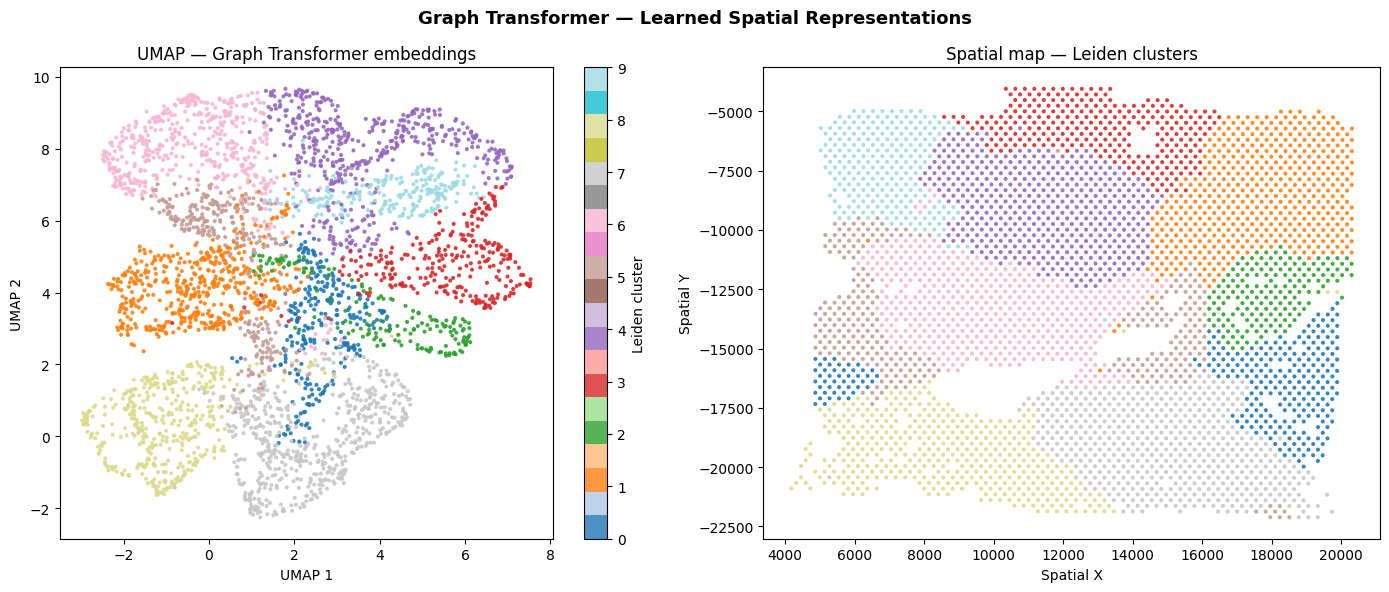

Saved: figures/umap/graph_transformer_umap.png


In [13]:
# compute umap and cluster (UMAP reduction + Leiden clustering on learned embeddings)
import umap
import scanpy as sc
import anndata as ad
from sklearn.preprocessing import StandardScaler

# load graph adata to attach results
adata = ad.read_h5ad("data/processed/adata_graph.h5ad")
adata.obsm["X_graph_transformer"] = Z_np

# UMAP on learned embeddings
scaler = StandardScaler()
Z_scaled = scaler.fit_transform(Z_np)

reducer = umap.UMAP(
    n_neighbors=cfg["umap"]["n_neighbors"],
    min_dist=cfg["umap"]["min_dist"],
    n_components=cfg["umap"]["n_components"],
    metric=cfg["umap"]["metric"],
    random_state=cfg["seed"],
)
Z_umap = reducer.fit_transform(Z_scaled)
adata.obsm["X_umap_gt"] = Z_umap
print("UMAP shape:", Z_umap.shape)

# Leiden clustering via scanpy neighbor graph on learned embeddings
sc.pp.neighbors(adata, use_rep="X_graph_transformer", n_neighbors=15, random_state=cfg["seed"])
sc.tl.leiden(adata, resolution=cfg["clustering"]["resolution"], random_state=cfg["seed"], flavor="igraph", n_iterations=2)
n_clusters = adata.obs["leiden"].nunique()
print(f"Leiden clusters: {n_clusters}")

# plot UMAP colored by cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter = axes[0].scatter(
    Z_umap[:, 0], Z_umap[:, 1],
    c=adata.obs["leiden"].astype(int),
    cmap="tab20", s=4, alpha=0.8
)
axes[0].set_title("UMAP — Graph Transformer embeddings")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")
plt.colorbar(scatter, ax=axes[0], label="Leiden cluster")

coords = adata.obsm["spatial"]
axes[1].scatter(
    coords[:, 0], -coords[:, 1],
    c=adata.obs["leiden"].astype(int),
    cmap="tab20", s=4, alpha=0.8
)
axes[1].set_title("Spatial map — Leiden clusters")
axes[1].set_xlabel("Spatial X")
axes[1].set_ylabel("Spatial Y")

plt.suptitle("Graph Transformer — Learned Spatial Representations", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/umap/graph_transformer_umap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/umap/graph_transformer_umap.png")

In [14]:
# evaluate_embeddings

from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors as KNN

labels = adata.obs["leiden"].astype(int).values

# silhouette score on learned embeddings
sil = silhouette_score(Z_scaled, labels, sample_size=2000, random_state=cfg["seed"])
print(f"Silhouette score (Graph Transformer): {sil:.4f}")

# neighborhood preservation: do spatial neighbors stay neighbors in embedding space?
k = cfg["evaluation"]["n_neighbors_preservation"]

knn_spatial = KNN(n_neighbors=k).fit(coords)
knn_embed   = KNN(n_neighbors=k).fit(Z_scaled)

nbrs_spatial = knn_spatial.kneighbors(coords,   return_distance=False)
nbrs_embed   = knn_embed.kneighbors(Z_scaled,   return_distance=False)

overlap = np.mean([
    len(set(nbrs_spatial[i]) & set(nbrs_embed[i])) / k
    for i in range(len(Z_scaled))
])
print(f"Neighborhood preservation (k={k})     : {overlap:.4f}")

# PCA baseline silhouette for comparison
Z_pca = adata.obsm["X_pca"]
Z_pca_scaled = StandardScaler().fit_transform(Z_pca)
sc.pp.neighbors(adata, use_rep="X_pca", n_neighbors=15,
                random_state=cfg["seed"], key_added="pca_neighbors")
sc.tl.leiden(adata, resolution=cfg["clustering"]["resolution"],
             random_state=cfg["seed"], neighbors_key="pca_neighbors",
             flavor="igraph", n_iterations=2, key_added="leiden_pca")
sil_pca = silhouette_score(Z_pca_scaled, adata.obs["leiden_pca"].astype(int),
                           sample_size=2000, random_state=cfg["seed"])
print(f"\nSilhouette score (PCA baseline)       : {sil_pca:.4f}")
print(f"Silhouette improvement                : {sil - sil_pca:+.4f}")

Silhouette score (Graph Transformer): 0.0146
Neighborhood preservation (k=15)     : 0.5332

Silhouette score (PCA baseline)       : -0.0021
Silhouette improvement                : +0.0167


In [15]:
# save evaluation results
import json

metrics = {
    "graph_transformer": {
        "silhouette_score"          : round(float(sil), 4),
        "neighborhood_preservation" : round(float(overlap), 4),
        "n_clusters"                : int(n_clusters),
    },
    "pca_baseline": {
        "silhouette_score"          : round(float(sil_pca), 4),
        "n_clusters"                : int(adata.obs["leiden_pca"].nunique()),
    },
    "improvement": {
        "silhouette_delta"          : round(float(sil - sil_pca), 4),
    }
}

with open("outputs/metrics/evaluation.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

adata.write_h5ad("data/processed/adata_final.h5ad")

print("Saved: outputs/metrics/evaluation.json")
print("Saved: data/processed/adata_final.h5ad")
print(json.dumps(metrics, indent=2))

Saved: outputs/metrics/evaluation.json
Saved: data/processed/adata_final.h5ad
{
  "graph_transformer": {
    "silhouette_score": 0.0146,
    "neighborhood_preservation": 0.5332,
    "n_clusters": 10
  },
  "pca_baseline": {
    "silhouette_score": -0.0021,
    "n_clusters": 9
  },
  "improvement": {
    "silhouette_delta": 0.0167
  }
}
